In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv("/content/Netflix Dataset 1.csv")
print("Shape:", df.shape)
df.head()


Shape: (7789, 11)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [78]:
print("\n📋 Dataset Info:\n")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

#Columns have spaces & inconsistent casing
df.columns = [c.strip().replace(" ", "_").lower() for c in df.columns]
print("\n Columns normalized:\n", df.columns.tolist())



📋 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        7787 non-null   object        
 1   category       7787 non-null   object        
 2   title          7787 non-null   object        
 3   director       7787 non-null   object        
 4   cast           7787 non-null   object        
 5   country        7787 non-null   object        
 6   release_date   7689 non-null   datetime64[ns]
 7   rating         7780 non-null   object        
 8   duration       7787 non-null   object        
 9   type           7787 non-null   object        
 10  description    7787 non-null   object        
 11  year           7787 non-null   float64       
 12  duration_num   7787 non-null   int64         
 13  duration_type  7787 non-null   object        
 14  content_type   7787 non-null   object        
dtypes: datet

In [59]:
df.type.value_counts()

,count
type,
Documentaries,334
Stand-Up Comedy,321
"Dramas, International Movies",320
"Comedies, Dramas, International Movies",243
"Dramas, Independent Movies, International Movies",215
...,...
"Crime TV Shows, International TV Shows, TV Sci-Fi & Fantasy",1
"Docuseries, Science & Nature TV, TV Action & Adventure",1
"British TV Shows, Classic & Cult TV, Kids' TV",1


In [79]:
# HANDLE DUPLICATES
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {df.duplicated().sum()} duplicate rows.")
else:
    print("No duplicate rows found.")


No duplicate rows found.


In [81]:
# HANDLE MISSING VALUE
print("\n Missing Values Before:\n", df.isnull().sum())

# Missing data in 'country', 'director', 'cast', 'release_date'
df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")

# Convert release_date to datetime and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['year'] = df['year'].fillna(df['year'].median())

print("\n Missing Values After:\n", df.isnull().sum())



 Missing Values Before:
 show_id           0
category          0
title             0
director          0
cast              0
country           0
release_date     98
rating            7
duration          0
type              0
description       0
year              0
duration_num      0
duration_type     0
content_type      0
dtype: int64

 Missing Values After:
 show_id           0
category          0
title             0
director          0
cast              0
country           0
release_date     98
rating            7
duration          0
type              0
description       0
year              0
duration_num      0
duration_type     0
content_type      0
dtype: int64


In [62]:
# SPLIT DURATION INTO VALUE & UNIT
#'duration' column mixes "min" and "Season(s)"
def split_duration(x):
    if pd.isna(x):
        return np.nan, np.nan
    parts = str(x).split()
    if len(parts) == 2:
        return int(parts[0]), parts[1]
    return np.nan, np.nan

df[['duration_num', 'duration_type']] = df['duration'].apply(lambda x: pd.Series(split_duration(x)))

print(" Duration column split into numeric value and unit type.")
df[['duration', 'duration_num', 'duration_type']].head()


 Duration column split into numeric value and unit type.


,duration,duration_num,duration_type
0,4 Seasons,4,Seasons
1,93 min,93,min
2,78 min,78,min
3,80 min,80,min
4,123 min,123,min


In [63]:
# STRIP TEXT SPACES
# Extra spaces & inconsistent casing in text columns
text_cols = ['title', 'director', 'cast', 'country', 'category', 'type', 'description']
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print("Whitespace removed and text cleaned.")


Whitespace removed and text cleaned.


In [64]:
# SUMMARY OF CLEANING
print("Final shape:", df.shape)
print("\nMissing values remaining:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Final shape: (7787, 14)

Missing values remaining:
 show_id           0
category          0
title             0
director          0
cast              0
country           0
release_date     98
rating            7
duration          0
type              0
description       0
year              0
duration_num      0
duration_type     0
dtype: int64

Data types:
 show_id                  object
category                 object
title                    object
director                 object
cast                     object
country                  object
release_date     datetime64[ns]
rating                   object
duration                 object
type                     object
description              object
year                    float64
duration_num              int64
duration_type            object
dtype: object


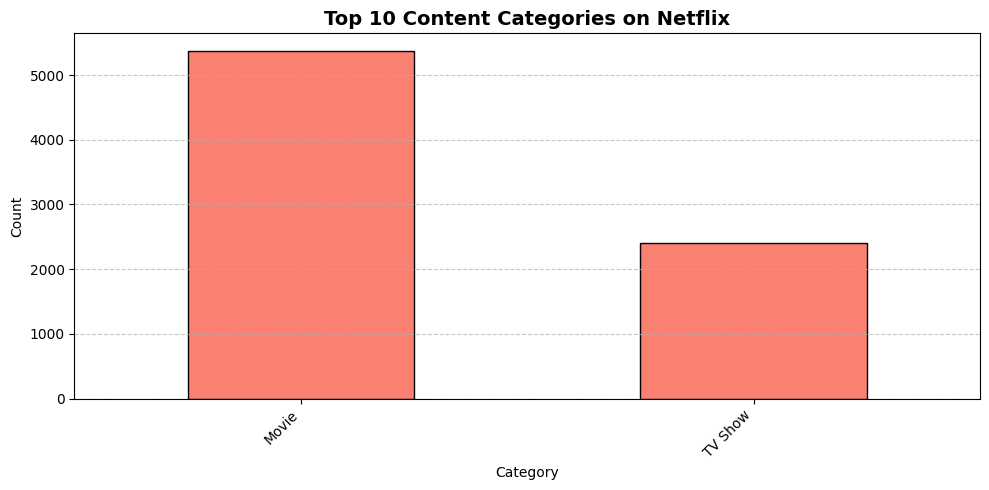

In [66]:
# EXPLORATORY DATA ANALYSIS (EDA)
# 1)Content Type Distribution
plt.figure(figsize=(10,5))
df['category'].value_counts().head(10).plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Top 10 Content Categories on Netflix", fontsize=14, weight='bold')
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



 Top 10 Content-Producing Countries:
 country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Name: count, dtype: int64


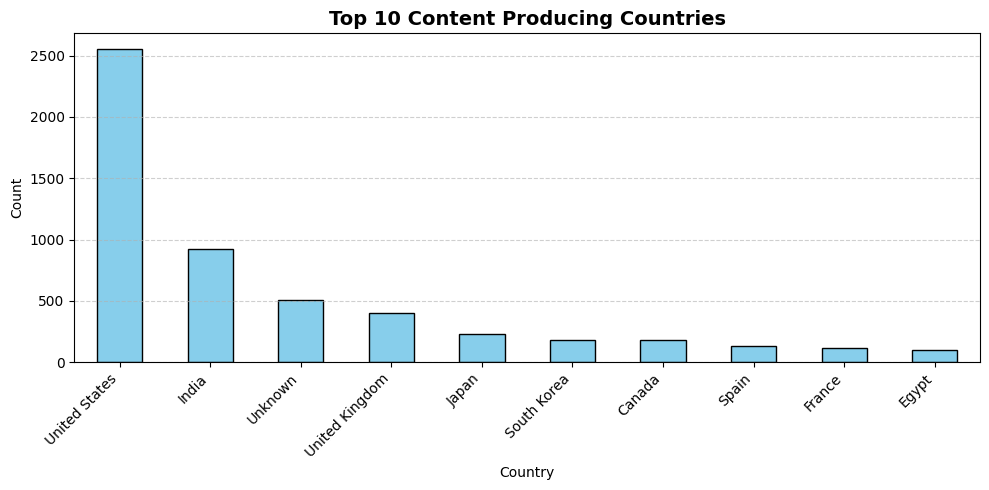

In [82]:
# 2)Country-wise Content Distribution
top_countries = df['country'].value_counts().head(10)
print("\n Top 10 Content-Producing Countries:\n", top_countries)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Top 10 Content Producing Countries", fontsize=14, weight='bold')
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Most content originates from the US, India, and UK.


 Number of Releases by Year:
 year
2017.0    1201
2018.0    1661
2019.0    2234
2020.0    2008
2021.0     117
Name: count, dtype: int64


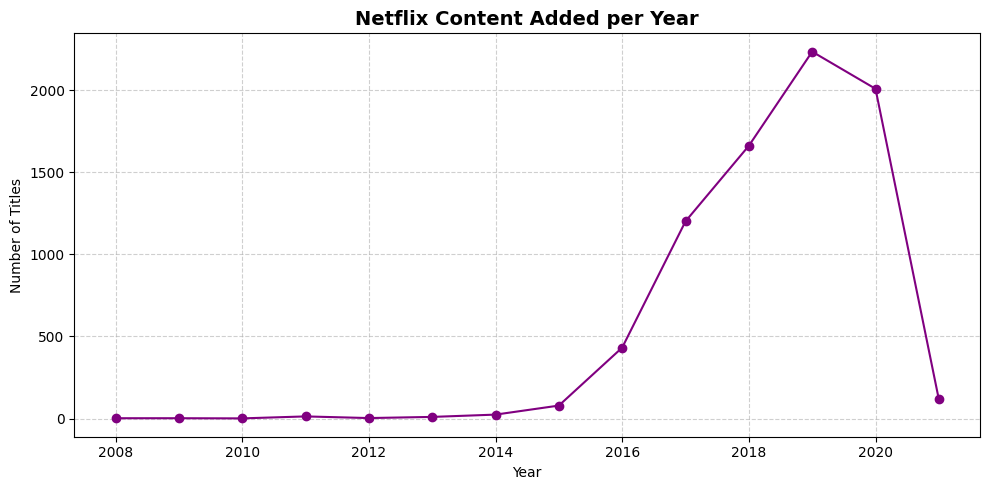

In [83]:
# 3)Yearly Trend of Netflix Additions
year_counts = df['year'].value_counts().sort_index()
print("\n Number of Releases by Year:\n", year_counts.tail())

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o', color='purple')
plt.title("Netflix Content Added per Year", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Netflix has grown sharply since 2015.


 Movie duration summary:
 count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64


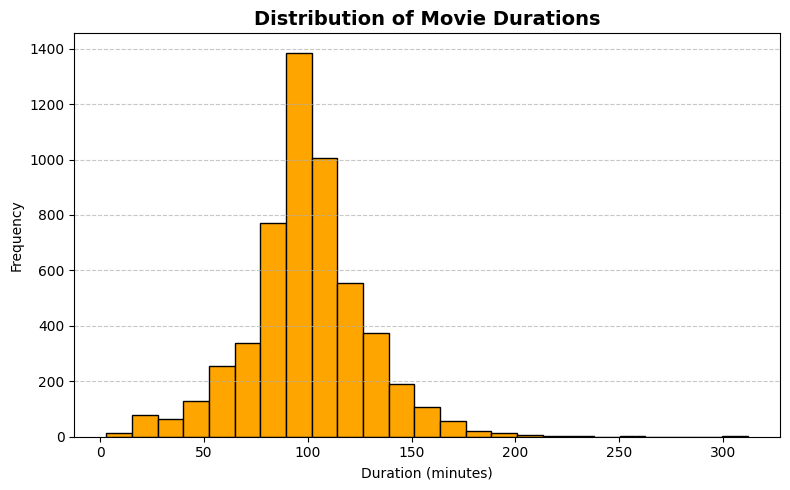

In [84]:
# 4)Duration Distribution (Movies)
movies = df[df['duration_type'] == 'min']
print("\n Movie duration summary:\n", movies['duration_num'].describe())

plt.figure(figsize=(8,5))
plt.hist(movies['duration_num'], bins=25, color='orange', edgecolor='black')
plt.title("Distribution of Movie Durations", fontsize=14, weight='bold')
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Typical movie duration is 80–120 minutes.


 Movies vs TV Shows count:
 content_type
Movie      5377
TV Show    2410
Name: count, dtype: int64


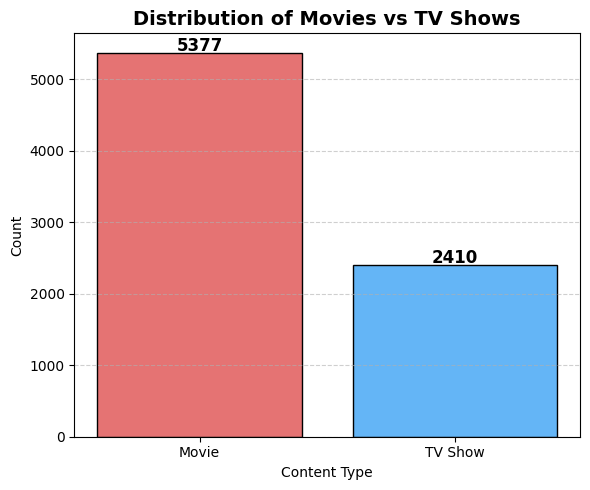

In [85]:
# 5)TV Shows vs Movies Classification
# Dataset doesn’t explicitly say “Movie” vs “TV Show” so can be found out through duration

df['content_type'] = np.where(df['duration_type'].str.lower().str.contains('season'), 'TV Show', 'Movie')

type_counts = df['content_type'].value_counts()
print("\n Movies vs TV Shows count:\n", type_counts)

plt.figure(figsize=(6,5))
bars = plt.bar(type_counts.index, type_counts.values, color=['#E57373','#64B5F6'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, int(bar.get_height()),
             ha='center', fontsize=12, fontweight='bold')
plt.title("Distribution of Movies vs TV Shows", fontsize=14, weight='bold')
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


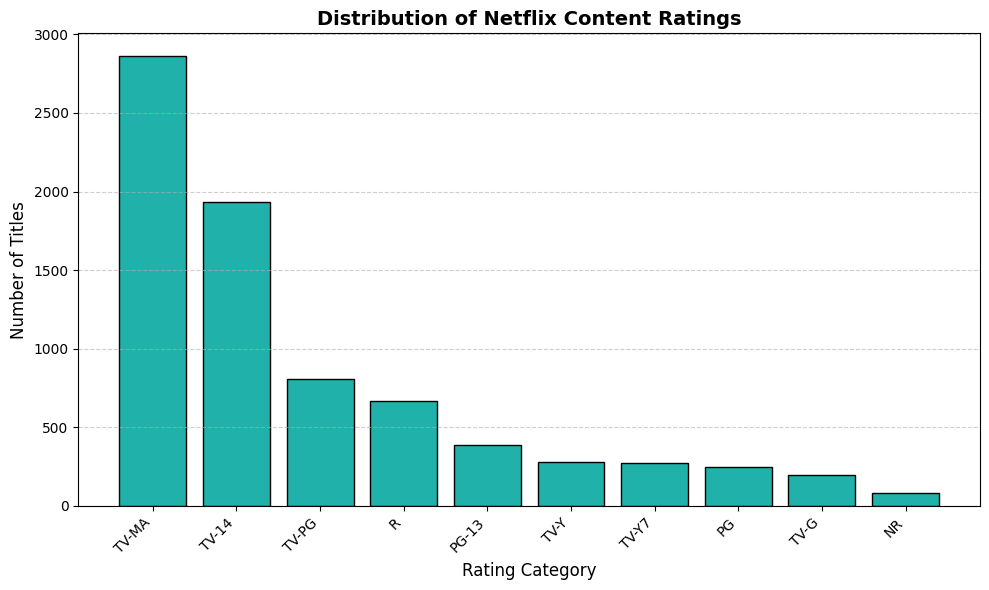

Rating-wise distribution:
 rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64


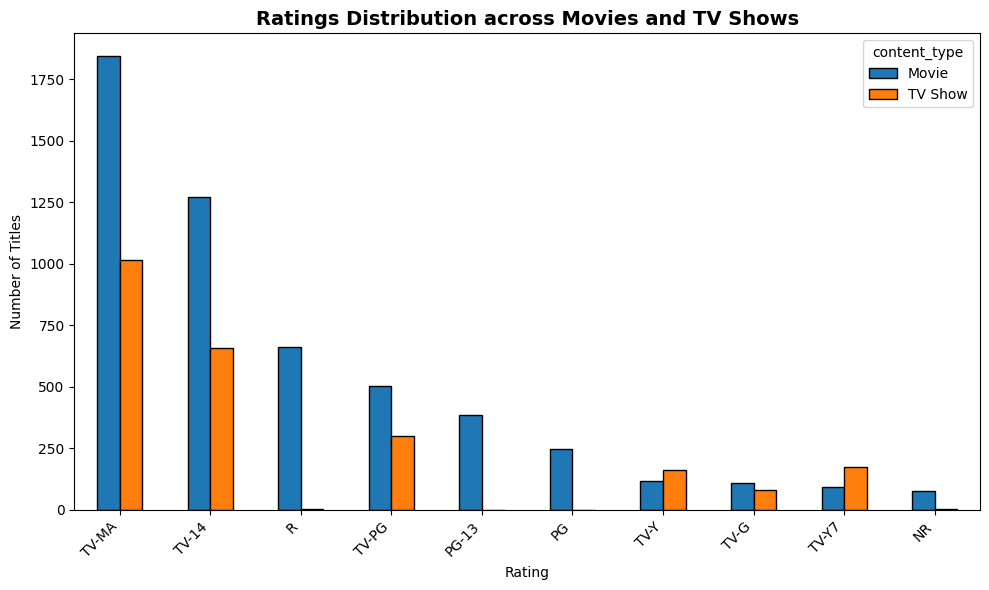

In [71]:
# Analyze how content ratings relate to frequency of releases
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(rating_counts.index, rating_counts.values, color='lightseagreen', edgecolor='black')
plt.title("Distribution of Netflix Content Ratings", fontsize=14, weight='bold')
plt.xlabel("Rating Category", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Rating-wise distribution:\n", rating_counts)

# Group by both rating and content type
rating_type = df.groupby(['rating','content_type']).size().unstack(fill_value=0).sort_values(by='Movie', ascending=False)
rating_type.head(10).plot(kind='bar', figsize=(10,6), edgecolor='black')
plt.title("Ratings Distribution across Movies and TV Shows", fontsize=14, weight='bold')
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


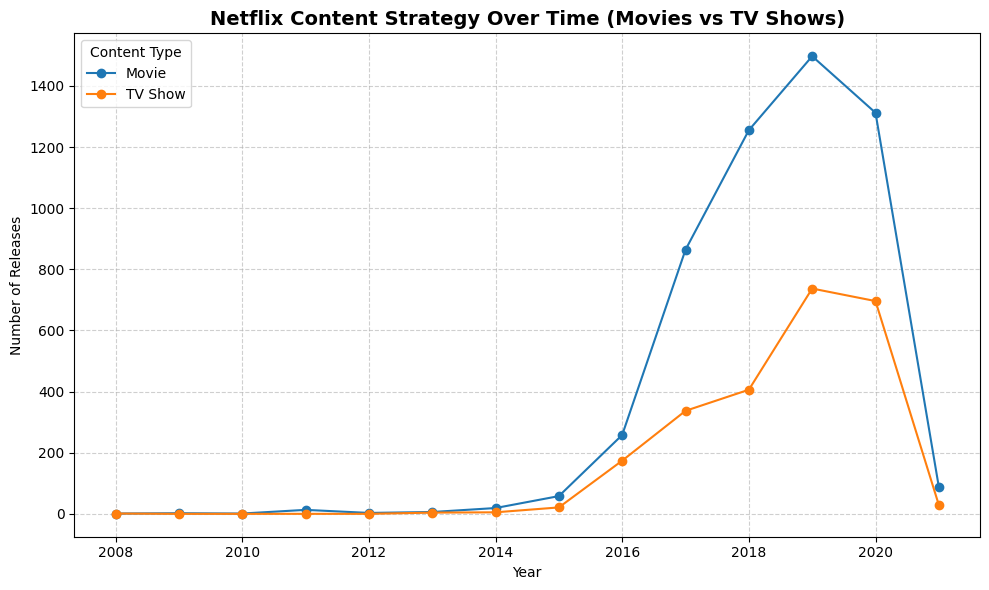

Evolution of Netflix content strategy:

content_type  Movie  TV Show
year                        
2017.0          864      337
2018.0         1255      406
2019.0         1497      737
2020.0         1312      696
2021.0           88       29


In [72]:
# Compare Movie vs TV Show distribution by year
type_trend = df.groupby(['year','content_type']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
for col in type_trend.columns:
    plt.plot(type_trend.index, type_trend[col], marker='o', label=col)
plt.title("Netflix Content Strategy Over Time (Movies vs TV Shows)", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.legend(title='Content Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Evolution of Netflix content strategy:\n")
print(type_trend.tail())


As observed both the movies n tv shows evolved after 2015 and it faced a downfall together in 2019.

/tmp/ipython-input-4294241160.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




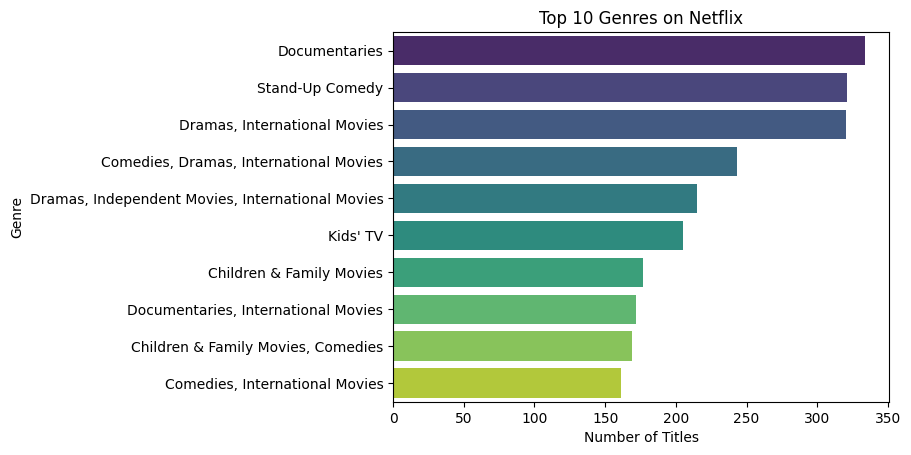

In [73]:
top_genres = df['type'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

The top 3 genres on Netflix among all other genres are documentaries,stand-up comedy and dramas,international movies.

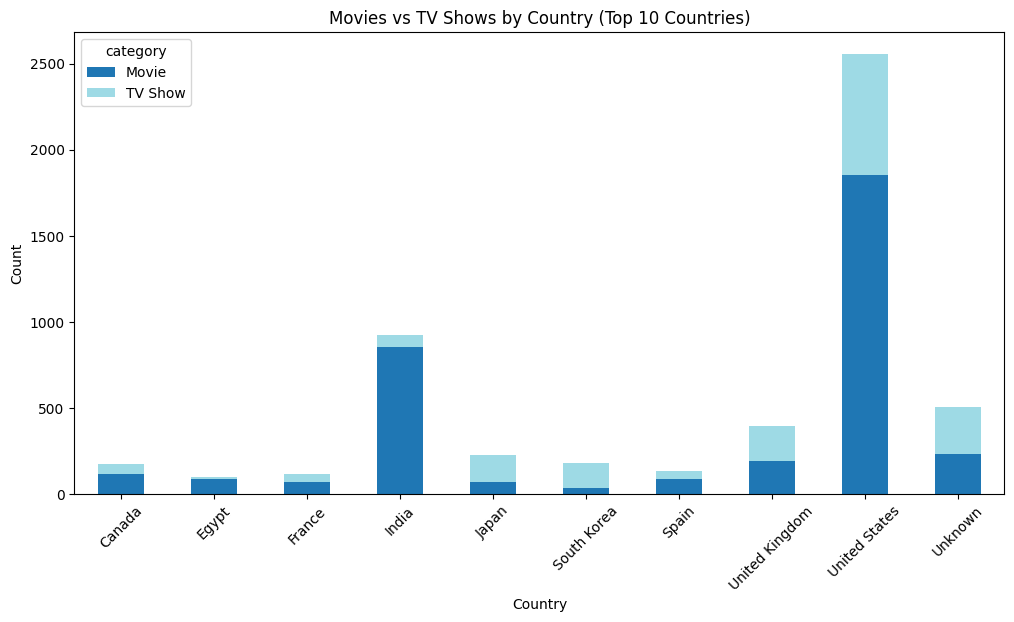

In [75]:
#Stacked Bar Chart – Movies vs TV Shows per Country (Top 10 countries)
top_countries = df['country'].value_counts().head(10).index
country_data = df[df['country'].isin(top_countries)]
stacked = country_data.groupby(['country', 'category']).size().unstack(fill_value=0)
stacked.plot(kind='bar', stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Movies vs TV Shows by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [76]:
#Choropleth Map – Country-wise Content
import plotly.express as px

country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
fig = px.choropleth(country_counts, locations="country", locationmode="country names",
                    color="count", hover_name="country",
                    color_continuous_scale="viridis", title="Netflix Content by Country")
fig.show()

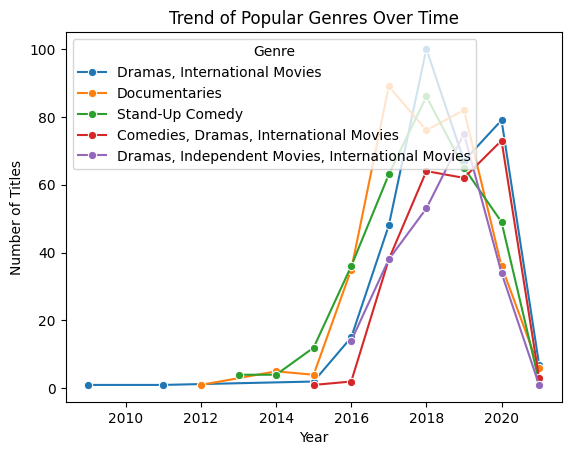

In [77]:
#Trend Line – Growth of Popular Genres Over Time
popular_genres = df['type'].value_counts().head(5).index
genre_trends = df[df['type'].isin(popular_genres)].groupby(['year','type']).size().reset_index(name='Count')

sns.lineplot(data=genre_trends, x='year', y='Count', hue='type', marker="o")
plt.title("Trend of Popular Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Genre")
plt.show()